# Task-02: Data Cleaning and Exploratory Data Analysis (EDA) on Titanic Dataset

**1. Objective**

The aim of this task is to:

*   clean the Titanic dataset
*   explore the important variables


*   study relationships between features,
*   identify patterns and trends affecting survival.





**2. Python Code with Step-by-Step Interpretation**

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# display settings
pd.set_option('display.max_columns', None)

**Step 1: Import Libraries**

  We import:

->pandas for data handling,

->numpy for numerical work,

->matplotlib and seaborn for charts.

**Interpretation:** These  libraries help us clean the data, summarize it, and visualize patterns clearly.

In [ ]:
# Step 2: Load dataset
df = pd.read_csv("train.csv")

**Step 2: Load Dataset**

We load the Titanic dataset into a dataframe.

**Interpretation:** This step brings the dataset into Python so we can inspect and analyze passenger details such as age, gender, fare, and survival.

In [ ]:
# Step 3: View basic information
print("First 5 rows:")
df.head()

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("\nShape of dataset:")
print(df.shape)



Shape of dataset:
(891, 12)


In [ ]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
print("\nDataset info:")
print(df.info())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
print("\nStatistical summary:")
print(df.describe(include='all'))



Statistical summary:
        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000    0.383838    2.308642                  NaN   NaN   
std      257.353842    0.486592    0.836071                  NaN   NaN   
min        1.000000    0.000000    1.000000                  NaN   NaN   
25%      223.500000    0.000000    2.000000                  NaN   NaN   
50%      446.000000    0.000000    3.000000                  NaN   NaN   
75%      668.500000    1.000000    3.000000                  NaN   NaN   
max      891.000000    1.000000    3.000000                  NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare Cabin Embarked  
count   7

**Step 3: Basic Information**

We check:

-->first few rows,

-->shape,

-->column names,

-->datatypes,

-->summary statistics.

**Interpretation**

1)This helps us understand:

2)how many rows and columns exist,

3)what each feature means,

4)whether columns are numeric or categorical,

5)whether the dataset looks clean or not.

**For Titanic, common columns include:**
Survived, Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

In [ ]:
# Step 4: Check missing values
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Step 4: Missing Values**

We check null values in each column.

**Interpretation:** In the Titanic dataset, missing values usually appear in:

->Age

->Cabin

->Embarked

This means some passenger information is incomplete and needs cleaning before analysis.

In [ ]:
# Step 5: Data cleaning
# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)


/tmp/ipykernel_13007/3205992483.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


**Step 5: Data Cleaning**

We:


*   fill missing Age values with median,
*   fill missing Embarked with mode,

*   drop Cabin because it has too many missing values.

**Interpretation**



*   Median for Age is a good choice because age may contain outliers.
*   Mode for Embarked works because it is categorical.







In [ ]:
# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_13007/562875535.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [ ]:
# Drop Cabin because too many missing values
df.drop(columns=['Cabin'], inplace=True)


In [ ]:
# Verify missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Step 6: Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0


**Step 6: Duplicate Rows**

We check if repeated records exist.

**Interpretation**

->Duplicate rows can distort analysis.

->If duplicates are present, they should be removed.

->If there are no duplicates, the dataset is more reliable.

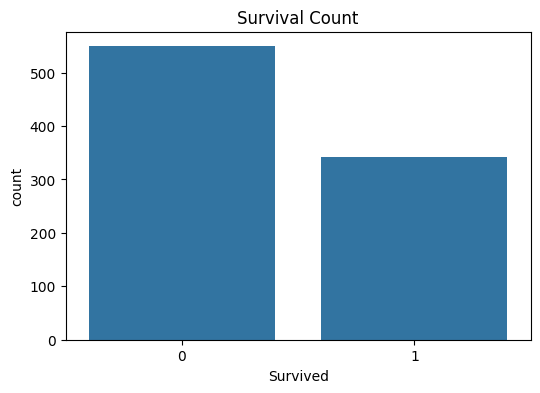

In [ ]:
# Step 7: Univariate Analysis

# Survival count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

**A. Survival Count**

This chart shows how many passengers survived and how many did not.

**Interpretation**

->**Usually, the Titanic dataset shows that:** more passengers did not survive than survived.

This indicates survival was difficult and unevenly distributed.

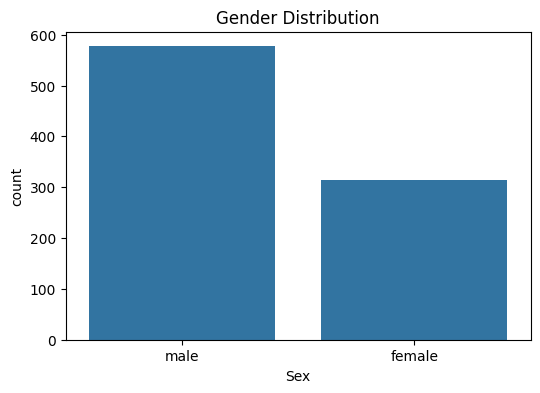

In [ ]:
# Gender count
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

**B. Gender Distribution**

This shows the number of male and female passengers.

**Interpretation:** Usually, there are more male passengers than female passengers in the dataset.

This is useful because gender is often strongly related to survival.

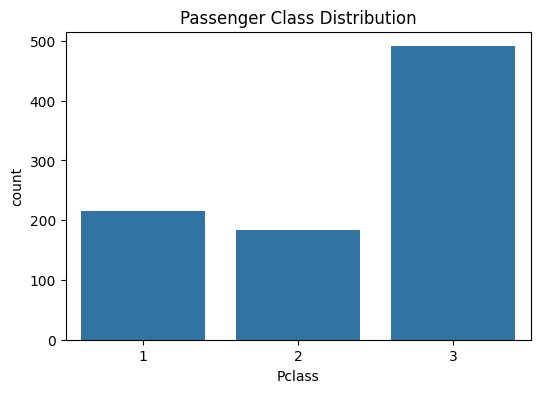

In [ ]:
# Passenger class count
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

**C. Passenger Class Distribution**

This shows how many passengers belonged to:


*   1st class
*   2nd class


*   3rd class

**Interpretation**

Usually, 3rd class has the highest number of passengers.

This matters because class reflects both ticket price and social status, which may affect survival chances.





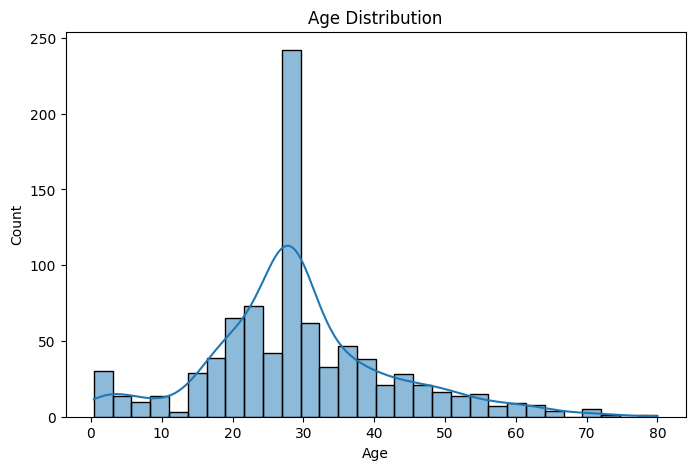

In [ ]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()


**D. Age Distribution**

Histogram of passenger ages.

Interpretation

This helps us see:

*   most passengers were young adults,
*   fewer passengers were very old,


*   there may be some children and infants.

Age helps us understand whether specific age groups had better survival chances.






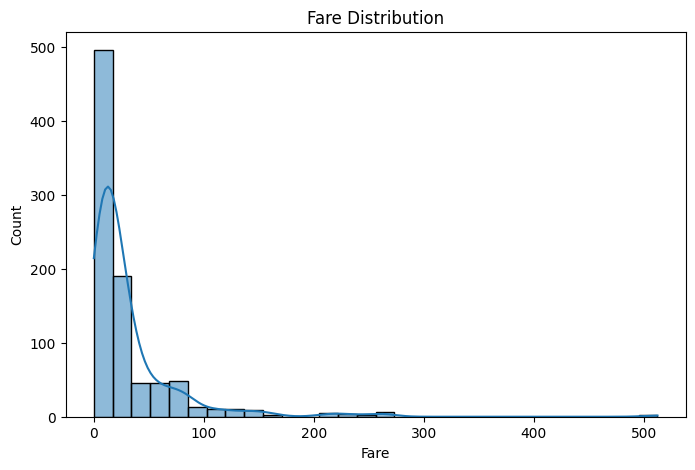

In [ ]:
# Fare distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()

**E. Fare Distribution**

Histogram of ticket fares.

**Interpretation**

Fare distribution is usually right-skewed, meaning:


*   many passengers paid low fares,
*   a few paid very high fares.

This suggests economic inequality among passengers and may connect with passenger class and survival.



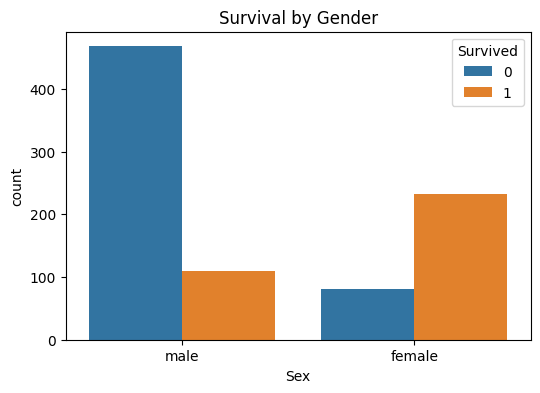

In [ ]:
# Step 8: Bivariate Analysis

# Survival by gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

**A. Survival by Gender**

This compares survival counts for males and females.

**Interpretation**

->**A common Titanic pattern is:** females had a much higher survival rate than males.This suggests that gender was one of the strongest factors influencing survival.

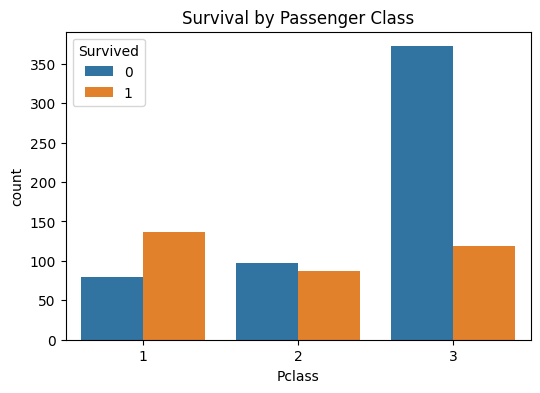

In [ ]:
# Survival by class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

**B. Survival by Passenger Class**

This compares survival in 1st, 2nd, and 3rd class.

**Interpretation**

Typical pattern:

->1st class passengers survived more

->3rd class passengers survived less

This indicates passenger class had a major effect on rescue access and safety.

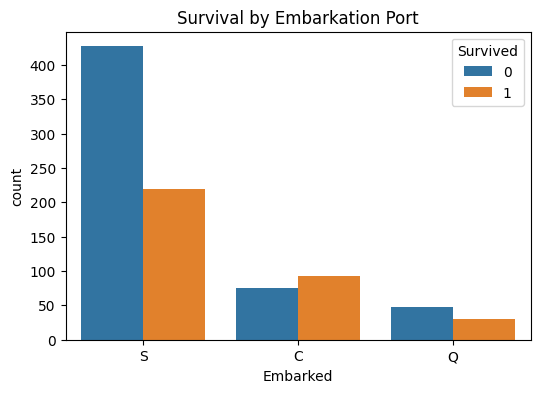

In [ ]:
# Survival by embarkation point
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Survival by Embarkation Port")
plt.show()

**C. Survival by Embarkation Port**

This compares survival by port:

S = Southampton

C = Cherbourg

Q = Queenstown

Interpretation

Different embarkation ports may show different survival rates because passenger groups boarding at each port had different class and fare profiles.

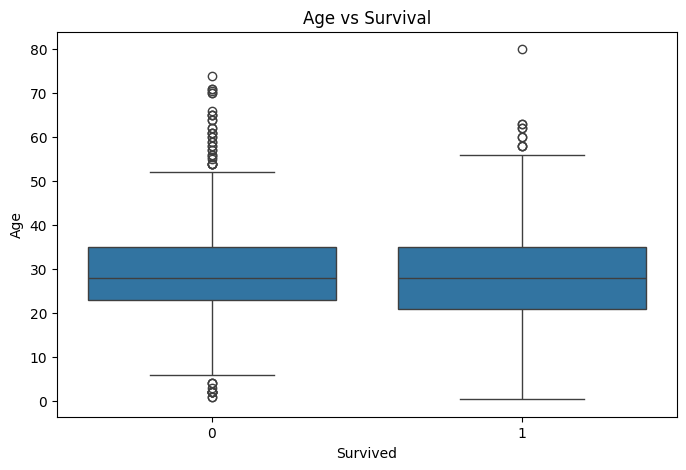

In [ ]:
# Age vs Survival
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

**D. Age vs Survival**

Boxplot compares age distributions of survivors and non-survivors.

**Interpretation**

This helps determine whether survivors were generally younger or older.
Often, children may show slightly better survival chances.

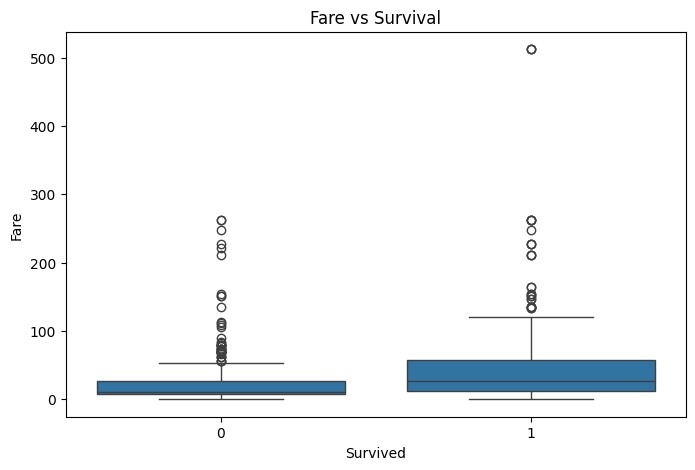

In [ ]:
# Fare vs Survival
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

**E. Fare vs Survival**

Boxplot compares fare paid by survivors vs non-survivors.

**Interpretation**

Passengers who paid higher fares often show higher survival rates.
This likely reflects the advantage of higher-class travel.

In [ ]:
# Step 9: Correlation analysis
# Convert categorical columns for correlation
df_corr = df.copy()
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

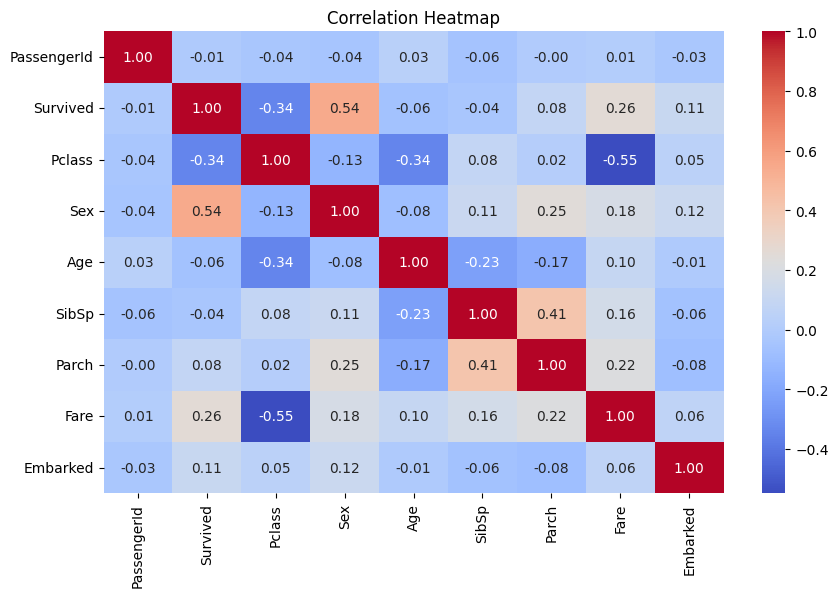

In [ ]:
# Select numeric columns
numeric_df = df_corr.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**6. Correlation Heatmap Interpretation**

The heatmap shows numeric relationships between variables.

**Interpretation:**

**Typical useful observations:**

->Pclass may have a negative relationship with survival if coded numerically, because lower class number means higher class.

->Fare often has a positive relationship with survival.

->Sex encoded numerically often shows strong relationship with survival.

->Age may show weaker correlation compared to gender and class.

This tells us that gender, passenger class, and fare are among the most important features.

In [ ]:
# Step 10: Group-wise insights
print("\nSurvival rate by gender:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by passenger class:")
print(df.groupby('Pclass')['Survived'].mean())

print("\nAverage fare by class:")
print(df.groupby('Pclass')['Fare'].mean())

print("\nSurvival rate by embarkation port:")
print(df.groupby('Embarked')['Survived'].mean())


Survival rate by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Average fare by class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Survival rate by embarkation port:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


# **Conclusion**

**From the Titanic EDA, the major patterns are:**

->Gender strongly influenced survival
Female passengers had a much higher survival rate than male passengers.

->Passenger class mattered a lot
1st class passengers survived more frequently than 2nd and 3rd class passengers.

->Fare is linked to survival
People who paid higher fares generally had better survival chances.

->Age had some effect, but weaker than gender and class
Children may have had slightly better chances in some cases.

->Data cleaning was necessary
Missing values in Age, Cabin, and Embarked had to be handled before analysis.

->Overall, the Titanic dataset shows that social class, gender, and ticket fare were the strongest factors affecting passenger survival.